<a href="https://colab.research.google.com/github/khalid-saqr/picoNewton/blob/main/picoNewton_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get clean
!apt-get update
!apt-get install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,910 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,773 kB]
Get:14 http://

In [2]:
# ==============================================================================
# Anisotropic Womersley Solver
# ------------------------------------------------------------------------------
# This solver is used in the paper: "A transverse piconewton-scale force field
# revealed in anisotropic Womersley flow" by Dr. Khalid Saqr
# The solver runs a complete, two-stage analysis using high-fidelity boundary
# conditions derived from digitized physiological waveforms and a physically
# consistent scaling framework.
# Copyright © Khalid Saqr. All rights reserved.
# ==============================================================================

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.colors import Normalize
from matplotlib.ticker import LogFormatterMathtext
from tqdm import tqdm

# ==============================================================================
# GLOBAL SETTINGS
# ==============================================================================
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,

        # TeX typography (JFM-grade)
        "text.usetex": False, # Changed from True to False to resolve RuntimeError
        "text.latex.preamble": r"""
            \usepackage{amsmath}
            \usepackage{mathptmx}
        """,

        "font.family": "serif",

        # Base font
        "font.size": 16,

        # Axis labels
        "axes.labelsize": 18,
        "axes.titlesize": 18,   # titles unused, keep consistent

        "xtick.labelsize": 15,
        "ytick.labelsize": 15,

        "legend.fontsize": 15,

        "mathtext.fontset": "cm",

        "axes.linewidth": 1.1,
        "lines.linewidth": 2.0,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.35,
    })

def save_fig(fig, stem: str):
    fig.savefig(os.path.join(FIGDIR, f"{stem}.png"))
    fig.savefig(os.path.join(FIGDIR, f"{stem}.pdf"))

def light_grid(ax):
    ax.grid(True, which="major")
    ax.minorticks_on()

def panel_label(ax, label: str):
    ax.text(0.86, 0.96, label, transform=ax.transAxes,
            ha="right", va="top", fontsize=16,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=1))

# ==============================================================================
# CORE SOLVER (Chebyshev spectral discretization)
# ==============================================================================
class WomersleySolver:
    def __init__(self, N: int):
        if N < 60:
            raise ValueError("Use N >= 60 for reasonable accuracy.")
        self.N = N
        self.n = N + 1
        self._setup_discretization()

    def _setup_discretization(self):
        k = np.arange(self.n)
        x = np.cos(np.pi * k / self.N)
        c = np.ones(self.n)
        c[0] = 2.0
        c[-1] = 2.0
        c *= (-1.0) ** k

        X = np.tile(x, (self.n, 1))
        dX = X - X.T + np.eye(self.n)
        D_cheb = (np.outer(c, 1.0 / c)) / dX
        D_cheb -= np.diag(np.sum(D_cheb, axis=1))

        # map x in [-1,1] to r in [0,1]
        self.r = (1.0 - x) / 2.0
        self.D = D_cheb * (-2.0)

        r_safe = self.r.copy()
        r_safe[0] = 1e-12
        invr = sp.diags(1.0 / r_safe)
        invr2 = sp.diags(1.0 / (r_safe ** 2))

        Dsp = sp.csr_matrix(self.D)
        D2sp = sp.csr_matrix(self.D @ self.D)

        self.L0 = D2sp + invr @ Dsp
        self.L1 = self.L0 - invr2

    def solve_harmonic(self, alpha, f_h, a_h, beta, gamma=None, delta=1.0):
        # allow symmetric coupling if gamma not provided
        if gamma is None:
            gamma = beta

        I = sp.eye(self.n, format="csr")
        Azz = (1j * f_h * alpha**2) * I - self.L0
        Azt = -beta * self.L1
        Atz = -gamma * self.L0
        Att = (1j * f_h * alpha**2) * I - delta * self.L1

        b_z = a_h * np.ones(self.n, dtype=complex)
        b_t = np.zeros(self.n, dtype=complex)

        Azzb, Aztb = Azz.tolil(), Azt.tolil()
        Attb, Atzb = Att.tolil(), Atz.tolil()
        bz, bt = b_z.copy(), b_t.copy()

        # BCs:
        # axial: symmetry at center (du/dr=0), no-slip at wall (u=0)
        # swirl: regular at center (u=0), no-slip at wall (u=0)
        Azzb[0, :], Aztb[0, :], bz[0] = self.D[0, :], 0.0, 0.0
        Azzb[-1, :], Azzb[-1, -1], Aztb[-1, :], bz[-1] = 0.0, 1.0, 0.0, 0.0

        Attb[0, :], Attb[0, 0], Atzb[0, :], bt[0] = 0.0, 1.0, 0.0, 0.0
        Attb[-1, :], Attb[-1, -1], Atzb[-1, :], bt[-1] = 0.0, 1.0, 0.0, 0.0

        A_top = sp.hstack([Azzb.tocsr(), Aztb.tocsr()])
        A_bot = sp.hstack([Atzb.tocsr(), Attb.tocsr()])
        A = sp.vstack([A_top, A_bot], format="csc")
        b = np.concatenate([bz, bt])

        sol = spla.spsolve(A, b)
        return sol[:self.n], sol[self.n:]

    def calculate_vorticity(self, Uz_h, Ut_h):
        r_safe = self.r.copy()
        r_safe[0] = 1e-12
        omega_theta = -(self.D @ Uz_h)
        omega_z = (1.0 / r_safe) * (self.D @ (self.r * Ut_h))
        return omega_z, omega_theta

# ==============================================================================
# PHYSICS HELPERS
# ==============================================================================
def force_per_cell_pN(force_density_scale, gl_value, V_cell, signed=False):
    """
    force_density_scale: rho * U0^2 / R  [Pa] (= N/m^2)
    gl_value: Lamb-vector-like dimensionless value (complex or real)
    V_cell: cell volume [m^3]
    returns pN
    """
    if signed:
        return force_density_scale * np.real(gl_value) * V_cell * 1e12
    return force_density_scale * np.abs(gl_value) * V_cell * 1e12

# ==============================================================================
# STAGE 1: FIGURES 1–2 (mono-harmonic)
# ==============================================================================
def make_figure1_and_2(solver: WomersleySolver):
    # Parameter sweep for Fig. 1
    alpha_range = np.linspace(1, 25, 50)
    beta_range = np.linspace(0.0, 0.2, 41)

    maps = {
        "ut_peak": np.zeros((len(beta_range), len(alpha_range))),
        "ut_loc":  np.zeros((len(beta_range), len(alpha_range))),
        "wz_peak": np.zeros((len(beta_range), len(alpha_range))),
        "F_pN":    np.zeros((len(beta_range), len(alpha_range))),
    }

    # Reference constants (consistent with prior code logic)
    rho = 1060.0
    mu = 3.5e-3
    G0_ref = 10000.0  # Pa/m
    V_cell = 1e-15    # m^3
    omega0 = 2 * np.pi * 1.2

    for i, beta in enumerate(tqdm(beta_range, desc="Figure 1 sweep (beta)")):
        for j, alpha in enumerate(alpha_range):
            f_h, a_h = 1.0, 1.0
            Uz_h, Ut_h = solver.solve_harmonic(alpha, f_h, a_h, beta)
            omega_z, omega_theta = solver.calculate_vorticity(Uz_h, Ut_h)

            gl = Ut_h * omega_z - Uz_h * omega_theta

            abs_Ut = np.abs(Ut_h)
            peak_idx = int(np.argmax(abs_Ut))

            maps["ut_peak"][i, j] = abs_Ut[peak_idx]
            maps["ut_loc"][i, j]  = solver.r[peak_idx]
            maps["wz_peak"][i, j] = np.max(np.abs(omega_z))

            # Reference scaling (as in your prior script)
            R_ref = alpha * np.sqrt(mu / (rho * omega0))
            U0_ref = G0_ref * R_ref**2 / mu
            force_density_scale = rho * (U0_ref**2) / R_ref

            # near-wall collocation point: index -2 (closest interior to wall)
            maps["F_pN"][i, j] = force_per_cell_pN(force_density_scale, gl[-2], V_cell, signed=False)

    # ---------------- Figure 1 layout (2x2) ----------------
    X, Y = np.meshgrid(alpha_range, beta_range)
    fig1, axes = plt.subplots(2, 2, figsize=(12.8, 10.6), constrained_layout=True)

    # (a) peak swirl magnitude
    ax = axes[0, 0]
    im = ax.contourf(X, Y, maps["ut_peak"], levels=25, cmap="viridis")
    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"$|\hat{u}_\theta|_{\max}$ (dimensionless)")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(a)")
    light_grid(ax)

    # (b) peak axial vorticity
    ax = axes[0, 1]
    im = ax.contourf(X, Y, maps["wz_peak"], levels=25, cmap="viridis")
    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"$|\hat{\omega}_z|_{\max}$ (dimensionless)")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(b)")
    light_grid(ax)

    # (c) location of peak swirl
    ax = axes[1, 0]
    im = ax.contourf(X, Y, maps["ut_loc"], levels=9, cmap="viridis")
    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"$r/R$")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(c)")
    light_grid(ax)

    # (d) transverse force magnitude (LINEAR)
    ax = axes[1, 1]

    # 1. Update vmin/vmax: No need to filter > 0 for linear scales.
    # Since it is a magnitude, vmin=0 is usually a good baseline.
    vmin = 0
    vmax = float(np.nanmax(maps["F_pN"]))

    # 2. Use Normalize instead of LogNorm (or just pass vmin/vmax directly)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # 3. Create the contour plot
    im = ax.contourf(X, Y, maps["F_pN"], levels=120, cmap="viridis", norm=norm)

    # thresholds (kept the same)
    cs = ax.contour(X, Y, maps["F_pN"], levels=[1.0, 10],
                    colors="white", linewidths=1.8, linestyles="--")
    ax.clabel(cs, inline=True, fontsize=12, fmt=lambda x: rf"{x:g}\,pN")

    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"Force per cell (pN)")

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(d)")
    light_grid(ax)

    save_fig(fig1, "Figure1")
    plt.close(fig1)

    # ---------------- Figure 2 (1x2) ----------------
    beta_fixed = 0.1
    alpha_list = [3.0, 8.0, 20.0]
    alpha_fixed = 8.0
    beta_list = [0.05, 0.10, 0.15, 0.20]

    fig2, axes = plt.subplots(1, 2, figsize=(12.8, 5.2), constrained_layout=True)

    # precompute for shared y-limits
    profiles_a = []
    ymax = 0.0
    for a in alpha_list:
        Uz, Ut = solver.solve_harmonic(a, 1.0, 1.0, beta_fixed)
        mag = np.abs(Ut)
        profiles_a.append((a, mag))
        ymax = max(ymax, float(np.max(mag)))

    profiles_b = []
    for b in beta_list:
        Uz, Ut = solver.solve_harmonic(alpha_fixed, 1.0, 1.0, b)
        mag = np.abs(Ut)
        profiles_b.append((b, mag))
        ymax = max(ymax, float(np.max(mag)))

    y_lim = 1.05 * ymax

    ax = axes[0]
    for a, mag in profiles_a:
        ax.plot(solver.r, mag, label=rf"$\alpha={a:g}$")
    ax.set_xlabel(r"$r/R$")
    ax.set_ylabel(r"$|\hat{u}_\theta|$ (dimensionless)")
    ax.set_ylim(0, y_lim)
    ax.legend(frameon=False, loc="upper left")
    panel_label(ax, r"(a)")
    light_grid(ax)

    ax = axes[1]
    for b, mag in profiles_b:
        ax.plot(solver.r, mag, label=rf"$\beta={b:g}$")
    ax.set_xlabel(r"$r/R$")
    ax.set_ylabel(r"$|\hat{u}_\theta|$ (dimensionless)")
    ax.set_ylim(0, y_lim)
    ax.legend(frameon=False, loc="upper left")
    panel_label(ax, r"(b)")
    light_grid(ax)

    save_fig(fig2, "Figure2")
    plt.close(fig2)

# ==============================================================================
# STAGE 2: FIGURES 3–6 (multi-harmonic, physiological cases)
# ==============================================================================
def make_figures_3_to_6(solver: WomersleySolver):
    rho = 1060.0
    nu = 3.5e-6
    mu = rho * nu
    omega0 = 2 * np.pi * 1.2

    V_cell = 1e-15       # m^3
    A_cell = 100e-12     # m^2 (used only for angle; kept for completeness)

    beta_sweep = np.linspace(0.0, 0.2, 11)
    beta_target = 0.1
    beta_idx = int(np.argmin(np.abs(beta_sweep - beta_target)))

    freqs = np.arange(1, 7)  # 1..6 harmonics

    # Cases: (name, R [m], G0 [Pa/m], amps for harmonics 1..6)
    phys_cases = [
        {"name": "Aortic Root",    "R": 0.015,  "G0": 9000, "amps": np.array([1.0, 0.82, 0.54, 0.33, 0.24, 0.17])},
        {"name": "Thoracic Aorta", "R": 0.012,  "G0": 7000, "amps": np.array([1.0, 0.76, 0.45, 0.28, 0.20, 0.12])},
        {"name": "Femoral",        "R": 0.004,  "G0": 6000, "amps": np.array([1.0, 0.58, 0.10, -0.17, 0.05, 0.04])},
        {"name": "Carotid",        "R": 0.0035, "G0": 6500, "amps": np.array([1.0, 0.63, 0.31, 0.15, 0.10, 0.06])},
        {"name": "Iliac",          "R": 0.0045, "G0": 5500, "amps": np.array([1.0, 0.51, 0.12, -0.11, 0.05, 0.03])},
        {"name": "Brachial",       "R": 0.002,  "G0": 4000, "amps": np.array([1.0, 0.49, 0.16, -0.05, 0.02, 0.01])},
    ]
    for case in phys_cases:
        case["alpha"] = case["R"] * np.sqrt(omega0 / nu)

    # Sort by alpha (descending) for consistent ordering
    sorted_cases = sorted(phys_cases, key=lambda c: c["alpha"], reverse=True)
    colors = cm.viridis(np.linspace(0, 1, len(sorted_cases)))

    # Compute results
    results = {}
    t_recon = np.linspace(0, 1, 150)

    for case in sorted_cases:
        name = case["name"]
        R = case["R"]
        G0 = case["G0"]
        alpha = case["alpha"]
        amps = case["amps"]

        U0_case = G0 * R**2 / mu
        force_density_scale = rho * (U0_case**2) / R

        peak_force_vs_beta = []
        systole_profiles_by_beta = []

        for beta in tqdm(beta_sweep, desc=f"Sweep beta for {name}", leave=False):
            H = len(freqs)
            Uz_h = np.zeros((solver.n, H), dtype=complex)
            Ut_h = np.zeros((solver.n, H), dtype=complex)
            gl_h = np.zeros((solver.n, H), dtype=complex)

            for h in range(H):
                G_h = G0 * amps[h]
                a_h = (G_h * R**2) / (mu * U0_case)  # dimensionless forcing amplitude
                Uz_h[:, h], Ut_h[:, h] = solver.solve_harmonic(alpha, freqs[h], a_h, beta)
                omega_z, omega_theta = solver.calculate_vorticity(Uz_h[:, h], Ut_h[:, h])
                gl_h[:, h] = Ut_h[:, h] * omega_z - Uz_h[:, h] * omega_theta

            # reconstruct time signals
            u_theta_t = np.zeros((solver.n, len(t_recon)), dtype=complex)
            u_z_t = np.zeros((solver.n, len(t_recon)), dtype=complex)
            gl_t = np.zeros((solver.n, len(t_recon)), dtype=complex)

            for h in range(H):
                time_ev = np.exp(1j * 2 * np.pi * freqs[h] * t_recon)
                u_theta_t += np.outer(Ut_h[:, h], time_ev)
                u_z_t += np.outer(Uz_h[:, h], time_ev)
                gl_t += np.outer(gl_h[:, h], time_ev)

            # define systole as max axial centerline velocity (same as your prior script logic)
            idx_systole = int(np.argmax(np.real(u_z_t[0, :])))
            systole_profiles_by_beta.append(np.real(u_theta_t[:, idx_systole]))

            # magnitude-only peak force at near-wall point (for Fig. 4)
            F_wall_mag = force_per_cell_pN(force_density_scale, gl_t[-2, :], V_cell, signed=False)
            peak_force_vs_beta.append(float(np.max(F_wall_mag)))

        results[name] = {
            "alpha": alpha,
            "peak_force_vs_beta": np.array(peak_force_vs_beta),
            "systole_profiles_by_beta": systole_profiles_by_beta,
            "R": R,
            "G0": G0,
            "amps": amps,
            "U0_case": U0_case,
            "force_density_scale": force_density_scale,
        }

    # ---------------- Figure 3: swirl profiles at peak systole (beta=0.1) ----------------
    fig3, ax = plt.subplots(figsize=(8.8, 6.8), constrained_layout=True)
    for i, case in enumerate(sorted_cases):
        name = case["name"]
        prof = results[name]["systole_profiles_by_beta"][beta_idx]
        ax.plot(solver.r, prof, color=colors[i], label=rf"{name} ($\alpha={results[name]['alpha']:.1f}$)")
    ax.set_xlabel(r"$r/R$")
    ax.set_ylabel(r"$u_\theta/U_0$ (dimensionless)")
    ax.legend(frameon=False, loc="best")
    #panel_label(ax, r"(a)")
    light_grid(ax)
    save_fig(fig3, "Figure3")
    plt.close(fig3)

    # ---------------- Figure 4: peak transverse force vs beta (log y) ----------------
    fig4, ax = plt.subplots(figsize=(8.8, 6.8), constrained_layout=True)
    for i, case in enumerate(sorted_cases):
        name = case["name"]
        ax.plot(beta_sweep, results[name]["peak_force_vs_beta"], color=colors[i], label=name)
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"Force per cell (pN)")
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 20)
    ax.legend(frameon=False, loc="lower left")
    # panel_label(ax, r"(a)")
    light_grid(ax)
    save_fig(fig4, "Figure4")
    plt.close(fig4)

    # ---------------- Figure 5: bar chart at beta=0.1 with threshold line ----------------
    fig5, ax = plt.subplots(figsize=(10.8, 6.6), constrained_layout=True)

    names = [c["name"] for c in sorted_cases]
    peak_vals = [float(results[n]["peak_force_vs_beta"][beta_idx]) for n in names]
    x = np.arange(len(names))

    ax.bar(x, peak_vals, edgecolor="k", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25, ha="right")
    ax.set_ylabel(r"Peak transverse force per cell (pN)")
    ax.set_yscale("log")
    ax.set_ylim(1e-2, 20)

    # reference threshold (0.1 pN)
    ax.axhline(0.1, linestyle="--", linewidth=1.6, color="k")

    # panel_label(ax, r"(a)")
    light_grid(ax)
    save_fig(fig5, "Figure5")
    plt.close(fig5)

    # ---------------- Figure 6: spatiotemporal SIGNED force maps (beta=0.1) ----------------
    t = np.linspace(0, 1, 128)
    r_grid, t_grid = np.meshgrid(solver.r, t)

    force_maps = []
    angle_maps = []
    max_abs = 0.0

    for case in sorted_cases:
        name = case["name"]
        R = results[name]["R"]
        G0 = results[name]["G0"]
        alpha = case["alpha"]
        amps = case["amps"]
        U0_case = results[name]["U0_case"]
        force_density_scale = results[name]["force_density_scale"]

        gl_t = np.zeros((solver.n, len(t)), dtype=complex)
        wss_t = np.zeros(len(t), dtype=complex)  # for angle only

        for h in range(len(freqs)):
            G_h = G0 * amps[h]
            a_h = (G_h * R**2) / (mu * U0_case)
            Uz_h, Ut_h = solver.solve_harmonic(alpha, freqs[h], a_h, beta_target)
            omega_z, omega_theta = solver.calculate_vorticity(Uz_h, Ut_h)
            gl_h = Ut_h * omega_z - Uz_h * omega_theta

            # axial wall shear proxy for angle (kept consistent with your approach)
            wss_dimless = -(solver.D @ Uz_h)[-1]
            wss_physical = wss_dimless * (mu * U0_case / R)

            time_ev = np.exp(1j * 2 * np.pi * freqs[h] * t)
            gl_t += np.outer(gl_h, time_ev)
            wss_t += wss_physical * time_ev

        # transverse force map
        F_map = force_per_cell_pN(force_density_scale, gl_t, V_cell, signed=True)
        force_maps.append(F_map)

        # Angle at wall (optional contours): atan2(radial, axial)
        axial_force_pN = np.real(wss_t) * A_cell * 1e12
        radial_force_pN_wall = force_per_cell_pN(force_density_scale, gl_t[-2, :], V_cell, signed=True)
        angle_wall = np.arctan2(radial_force_pN_wall, axial_force_pN) * 180.0 / np.pi
        angle_map_2d = np.tile(angle_wall, (solver.n, 1))
        angle_maps.append(angle_map_2d)

        max_abs = max(max_abs, float(np.max(np.abs(F_map))))

    fig6, axes = plt.subplots(3, 2, figsize=(12.8, 14.2),
                             constrained_layout=True, sharex=True, sharey=True)

    if max_abs <= 0:
        max_abs = 1.0

    norm = SymLogNorm(linthresh=0.01 * max_abs, vmin=-max_abs, vmax=max_abs)
    mappable = None

    for i, case in enumerate(sorted_cases):
        ax = axes.flat[i]
        F = force_maps[i]
        A = angle_maps[i]

        mappable = ax.contourf(t_grid, r_grid, F.T, levels=49, cmap="seismic", norm=norm)

        # Optional angle contours (kept minimal)
        cs = ax.contour(t_grid, r_grid, A.T, levels=[-90, 0, 90],
                        colors="w", linestyles="--", linewidths=0.7)
        ax.clabel(cs, inline=True, fontsize=14, fmt=r"%1.0f$^\circ$")

        panel_label(ax, case["name"])
        light_grid(ax)

    for ax in axes[-1, :]:
        ax.set_xlabel(r"$t/T$")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$r/R$")

    cbar = fig6.colorbar(mappable, ax=axes, shrink=0.95, pad=0.02)
    cbar.set_label(r"Transverse force per cell (pN)")

    save_fig(fig6, "Figure6")
    plt.close(fig6)

# ==============================================================================
# MAIN
# ==============================================================================
def main():
    set_pub_style()
    solver = WomersleySolver(N=150)
    make_figure1_and_2(solver)
    make_figures_3_to_6(solver)
    print(f"Done. Figures saved to: ./{FIGDIR}/ (PNG + PDF)")

if __name__ == "__main__":
    main()

Figure 1 sweep (beta): 100%|██████████| 41/41 [03:12<00:00,  4.69s/it]


Done. Figures saved to: ./figures/ (PNG + PDF)


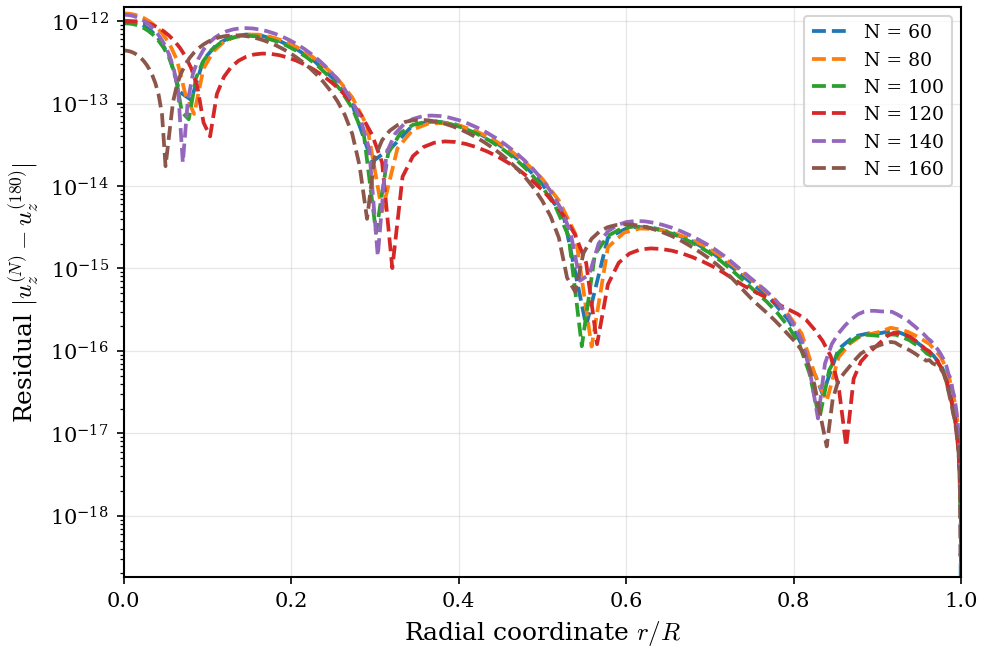

In [3]:
# ============================================================
# GRID-INDEPENDENCE FIGURE
# Spectral residual profiles
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

# ---------------- Typography (balanced journal style) ----------------
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
})

# ---------------- Refinement sequence ----------------
N_list = [60, 80, 100, 120, 140, 160]
N_prod = 150
N_ref  = 180

t_peak = 0.25

# ---------------- Profile computation ----------------
def axial_profile_at_time(N, t0):

    solver = WomersleySolver(N=N)

    rho = 1060.0
    nu  = 3.5e-6
    mu  = rho * nu
    omega0 = 2*np.pi*1.2
    freqs  = np.arange(1, 7)

    R = 0.012
    G0 = 7000
    amps = np.array([1.0, 0.76, 0.45, 0.28, 0.20, 0.12])

    U0_case = G0*R**2/mu
    alpha = R*np.sqrt(omega0/nu)

    H = len(freqs)
    Uz_h = np.zeros((solver.n, H), dtype=complex)

    for j, f in enumerate(freqs):
        G_h = G0*amps[j]
        a_h = (G_h*R**2)/(mu*U0_case)
        Uz_h[:, j], _ = solver.solve_harmonic(
            alpha, f, a_h, 0.1, 0.0, 1.0
        )

    u_z = np.zeros(solver.n, dtype=complex)
    for j, f in enumerate(freqs):
        u_z += Uz_h[:, j] * np.exp(1j*2*np.pi*f*t0)

    r = np.asarray(solver.r)
    uz = np.real(u_z)

    order = np.argsort(r)
    return r[order], uz[order]


# ---------------- Reference solution ----------------
r_ref, uz_ref = axial_profile_at_time(N_ref, t_peak)
ref_interp = BarycentricInterpolator(r_ref, uz_ref)

# ---------------- Residuals ----------------
residuals = {}
r_grids   = {}

for N in N_list:
    rN, uzN = axial_profile_at_time(N, t_peak)
    r_grids[N] = rN

    if N == N_ref:
        residuals[N] = np.zeros_like(rN)
    else:
        uz_ref_on_rN = ref_interp(rN)
        residuals[N] = np.abs(uzN - uz_ref_on_rN)

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(6.8, 4.6))

for N in N_list:
    if N == N_prod:
        ax.semilogy(r_grids[N], residuals[N],
                    linewidth=2.8,
                    label=f"N = {N} (production)")
    elif N == N_ref:
        ax.semilogy(r_grids[N], residuals[N],
                    linewidth=1.8,
                    color='black',
                    label=f"N = {N} (reference)")
    else:
        ax.semilogy(r_grids[N], residuals[N],
                    linestyle="--",
                    linewidth=1.8,
                    label=f"N = {N}")

ax.set_xlabel(r"Radial coordinate $r/R$")
ax.set_ylabel(r"Residual $|u_z^{(N)} - u_z^{(180)}|$")
ax.set_xlim(0, 1)
ax.grid(True, which="major", alpha=0.3)

# Tight y-limits
ymin = min(np.min(residuals[N][residuals[N] > 0]) for N in N_list if N != N_ref)
ymax = max(np.max(residuals[N]) for N in N_list)
ax.set_ylim(ymin*0.8, ymax*1.2)

ax.legend(frameon=True, loc="upper right")

plt.tight_layout()
plt.savefig("Fig_Methods_GridIndependence_Clean.pdf")
plt.show()